# Figure 1 — data-creation pipeline fields

Panels for the muchisimocks pipeline overview:
1. Initial conditions $\delta_\mathrm{IC}$ (`lin_field`)
2. Zel'dovich particle positions from $x = q + \Psi_\mathrm{ZA}(q)$ (`ZA_disp`)
3. Map2map particle positions from $x = q + \Psi(q)$ (`pred_disp`)
4. Bias operators, coupled noise, and tracer field
5. SHAMe OOD target: catalog positions, then the CIC+$k$-cut field on a $\sim 128^3$-equivalent grid (132³ for $L=1024\,\mathrm{Mpc}/h$)
6. Training-set portion: overlapping tracer stacks (cosmologies × bias params)
7. Training-set $P(k)$ ranges (Fig. 2 style, thicker / no labels)
8. SHAMe fiducial $P(k)$ (Fig. 2 color, thicker / no labels)

Displacements use a Lagrangian slab along $z$: $x = q + \Psi(q)$.

Primary source: `/data/.../muchisimocks_lib_p5_n10000_rerun/LH0`.

All panels show the **full xy box** (particle scatters and fields); depth is a thin z-slice / slab only.

Style: black axes, no ticks/labels/colorbar; 4×4 inch panels.


In [18]:
import sys
from pathlib import Path

try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    REPO_ROOT = Path.cwd()
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "code"))

import numpy as np
from matplotlib import pyplot as plt

import bacco

import paths

import sys
sys.path.append('/dipc/kstoreyf/muchisimocks/scripts')
import plotter

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
TAG_PARAMS = "_p5_n10000"
DIR_MOCKS = paths.mocks_lib_dir(TAG_PARAMS)

CANDIDATE_DIRS = [
    Path("/data/kstoreyf/muchisimocks/muchisimocks_lib_p5_n10000_rerun/LH0"),
    Path(str(DIR_MOCKS) + "_rerun") / "LH0",
    DIR_MOCKS / "LH0",
    DIR_MOCKS / "LH7316",
    paths.mocks_lib_ood_dir("shame") / "mock0",
]
REQUIRED = ("lin_field.npy", "ZA_disp.npy", "pred_disp.npy")

N_GRID = 512
BOX_SIZE = 1000.0  # Mpc/h
CELL = BOX_SIZE / N_GRID
N_SLICE = 20  # cells along z for 512³ projections
SLICE_WIDTH = N_SLICE * CELL  # ~39 Mpc/h; used to match physical depth on 128³ fields
Z0 = 0  # starting cell index for the projection

FIGSIZE = (4, 4)
# Match notebook inline render to savefig so scatters (esp. alpha + rasterized) look the same.
# Jupyter's default figure.dpi is ~100, which made on-screen panels look different from the PNGs.
DPI = 200
plt.rcParams["figure.dpi"] = DPI
plt.rcParams["savefig.dpi"] = DPI

FIG_DIR = REPO_ROOT / "figures" / "2026-09-03_figure1" / "figure1"
FIG_DIR_LATEST = REPO_ROOT / "figures" / "paper_figures_latest" / "figure1"
OVERWRITE_FIGURES = True
FIG_EXT = "png"

print(f"Slice: {N_SLICE} cells ≈ {SLICE_WIDTH:.1f} Mpc/h (cell={CELL:.3f} Mpc/h)")
print(f"Figure DPI: {DPI} (inline + save)")


def save_figure(fig, name, ext=FIG_EXT):
    """Save figure to FIG_DIR and FIG_DIR_LATEST; skip if exists and OVERWRITE_FIGURES is False."""
    filename = f"{name}.{ext}"
    paths_out = [FIG_DIR / filename, FIG_DIR_LATEST / filename]
    if any(p.exists() for p in paths_out) and not OVERWRITE_FIGURES:
        print(f"Skipping save (exists, overwrite=False): {filename}")
        return
    fig.canvas.draw_idle()
    for path in paths_out:
        path.parent.mkdir(parents=True, exist_ok=True)
        # Small pad so thick spines aren't clipped by the tight bbox (esp. lower/right).
        # facecolor="none" → transparent pad; do NOT pass transparent=True
        # (that also clears Axes patches, wiping white particle-plot backgrounds).
        fig.savefig(
            path,
            bbox_inches="tight",
            pad_inches=0.06,
            facecolor="none",
            edgecolor="none",
            dpi=DPI,
        )
        print(f"Saved: {path}")


def find_field_dir(candidates=CANDIDATE_DIRS, required=REQUIRED):
    missing_notes = []
    for d in candidates:
        if not d.is_dir():
            missing_notes.append(f"missing dir: {d}")
            continue
        present = {f: (d / f).is_file() for f in required}
        if all(present.values()):
            return d, missing_notes
        missing = [f for f, ok in present.items() if not ok]
        missing_notes.append(f"{d}: missing {missing}; has {[p.name for p in d.iterdir()]}")
    return None, missing_notes


Slice: 20 cells ≈ 39.1 Mpc/h (cell=1.953 Mpc/h)
Figure DPI: 200 (inline + save)


In [3]:
DIR_LH, notes = find_field_dir()
print("Lookup notes:")
for n in notes:
    print(" -", n)

if DIR_LH is None:
    raise FileNotFoundError(
        "No candidate directory has lin_field.npy + ZA_disp.npy + pred_disp.npy."
    )

print(f"\nUsing: {DIR_LH}")
FN_LIN = DIR_LH / "lin_field.npy"
FN_ZA = DIR_LH / "ZA_disp.npy"
FN_DISP = DIR_LH / "pred_disp.npy"
for fn in (FN_LIN, FN_ZA, FN_DISP):
    print(f"  {fn.name}: {fn.stat().st_size / 1e9:.2f} GB")

Lookup notes:

Using: /data/kstoreyf/muchisimocks/muchisimocks_lib_p5_n10000_rerun/LH0
  lin_field.npy: 0.54 GB
  ZA_disp.npy: 1.61 GB
  pred_disp.npy: 1.61 GB


In [4]:
def project_slice(field_3d, z0=Z0, n_slice=N_SLICE):
    """Mean over a contiguous z slab; full xy extent."""
    z1 = z0 + n_slice
    if z1 <= field_3d.shape[-1]:
        return np.mean(np.asarray(field_3d[:, :, z0:z1]), axis=-1)
    parts = [np.asarray(field_3d[:, :, z0:])]
    remaining = n_slice - (field_3d.shape[-1] - z0)
    parts.append(np.asarray(field_3d[:, :, :remaining]))
    return np.mean(np.concatenate(parts, axis=-1), axis=-1)


def load_disp_slab(path, z0=Z0, n_slice=N_SLICE):
    """Load a thin z-slab of Psi: (3, Nx, Ny, n_slice). mmap, ~30 MB not 1.6 GB."""
    disp = np.load(path, mmap_mode="r")
    return np.asarray(disp[:, :, :, z0:z0 + n_slice])


def displace_slab(disp_slab, z0=Z0):
    """Apply Psi to a Lagrangian grid: x = q + Psi(q)."""
    nx, ny, nz = disp_slab.shape[1:]
    ix = (np.arange(nx) + 0.5) * CELL
    iy = (np.arange(ny) + 0.5) * CELL
    iz = (np.arange(z0, z0 + nz) + 0.5) * CELL
    qx, qy, qz = np.meshgrid(ix, iy, iz, indexing="ij")
    x = (qx + disp_slab[0]) % BOX_SIZE
    y = (qy + disp_slab[1]) % BOX_SIZE
    z = (qz + disp_slab[2]) % BOX_SIZE
    return x, y, z


def eulerian_density_xy(x, y, nbins=N_GRID):
    """2D histogram density of displaced particles (1 + δ)."""
    H, _, _ = np.histogram2d(
        x.ravel(), y.ravel(), bins=nbins, range=[[0, BOX_SIZE], [0, BOX_SIZE]]
    )
    return H / H.mean()


def style_axes(ax, lw=2.5):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(length=0, labelbottom=False, labelleft=False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(lw)
        spine.set_clip_on(False)


# Sequential purple for density / 1-field panels (anchor #51103d)
from matplotlib.colors import LinearSegmentedColormap
DENSITY_PURPLE = "#51103d"
CMAP_DENSITY = LinearSegmentedColormap.from_list(
    "density_purple", ["#ffffff", DENSITY_PURPLE], N=256
)


def plot_field_panel(field_2d, vmax=None, transpose=False, diverging=False):
    """4x4 imshow of a full-box 2D field (z-slice already projected).

    Density-like fields use CMAP_DENSITY; signed fields use RdBu_r.
    """
    img = field_2d.T if transpose else field_2d
    if diverging:
        if vmax is None:
            vmax = 3 * np.std(img)
        vmin, cmap = -vmax, "RdBu_r"
    else:
        cmap = CMAP_DENSITY
        if vmax is None:
            vmax = np.percentile(img, 99)
        vmin = 0.0 if np.nanmin(img) >= 0 else np.percentile(img, 1)
    fig = plt.figure(figsize=FIGSIZE, dpi=DPI, facecolor="none")
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_facecolor("none")
    ax.imshow(
        img,
        origin="lower",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
        aspect="equal",
    )
    style_axes(ax)
    return fig


# Back-compat alias
def plot_overdensity_panel(*args, **kwargs):
    return plot_field_panel(*args, **kwargs)


def plot_particle_scatter(x, y, stride=4, alpha=0.4, s=0.4):
    """Full-box particle positions from displacement fields (ZA / map2map).

    stride downsamples the grid (every stride-th particle in each axis).
    Limits fixed to [0, L] so autoscaling doesn't leave an empty edge.
    """
    fig = plt.figure(figsize=FIGSIZE, dpi=DPI, facecolor="none")
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_facecolor("white")  # white inside axes; figure pad stays transparent
    xx = x[::stride, ::stride].ravel()
    yy = y[::stride, ::stride].ravel()
    ax.scatter(
        xx,
        yy,
        s=s,
        c="k",
        alpha=alpha,
        linewidths=0,
        rasterized=True,
    )
    ax.set_xlim(0, BOX_SIZE)
    ax.set_ylim(0, BOX_SIZE)
    ax.set_aspect("equal")
    style_axes(ax)
    return fig


def plot_catalog_scatter(
    pos_xyz, box_size, z0=0.0, z_width=None, s=3.0, alpha=0.55, color="darkgreen",
):
    """Full-box catalog scatter (SHAMe etc.) with a thin z-slice."""
    if z_width is None:
        z_width = SLICE_WIDTH
    x, y, z = pos_xyz[:, 0], pos_xyz[:, 1], pos_xyz[:, 2]
    m = (z >= z0) & (z < z0 + z_width)
    fig = plt.figure(figsize=FIGSIZE, dpi=DPI, facecolor="none")
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_facecolor("white")  # white inside axes; figure pad stays transparent
    ax.scatter(x[m], y[m], s=s, c=color, alpha=alpha, linewidths=0, rasterized=True)
    ax.set_xlim(0, box_size)
    ax.set_ylim(0, box_size)
    ax.set_aspect("equal")
    style_axes(ax)
    return fig


## Initial conditions $\delta_\mathrm{IC}$

delta_IC projection: (512, 512) std= 0.7867422103881836
Saved: /home/kstoreyf/muchisimocks/figures/2026-09-03_figure1/figure1/fig1_initial_conditions_delta_ic.png
Saved: /home/kstoreyf/muchisimocks/figures/paper_figures_latest/figure1/fig1_initial_conditions_delta_ic.png


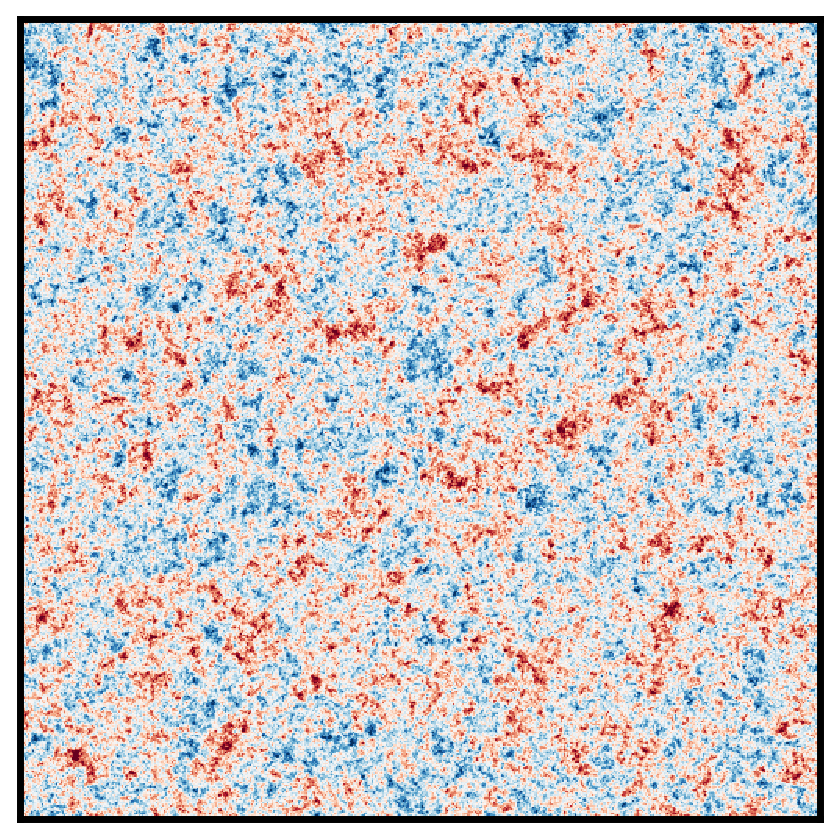

In [13]:
delta_ic_3d = np.load(FN_LIN, mmap_mode="r")
delta_ic = project_slice(delta_ic_3d)
print("delta_IC projection:", delta_ic.shape, "std=", float(np.std(delta_ic)))

fig = plot_field_panel(delta_ic, diverging=True)
save_figure(fig, "fig1_initial_conditions_delta_ic")
plt.show()


## Zel'dovich particles: $x = q + \Psi_\mathrm{ZA}(q)$ (full box)


In [14]:
print("Loading ZA displacement slab…")
disp_za = load_disp_slab(FN_ZA)
x_za, y_za, z_za = displace_slab(disp_za)
print("ZA particles:", x_za.shape)


Loading ZA displacement slab…
ZA particles: (512, 512, 20)


Saved: /home/kstoreyf/muchisimocks/figures/2026-09-03_figure1/figure1/fig1_za_particle_positions.png
Saved: /home/kstoreyf/muchisimocks/figures/paper_figures_latest/figure1/fig1_za_particle_positions.png


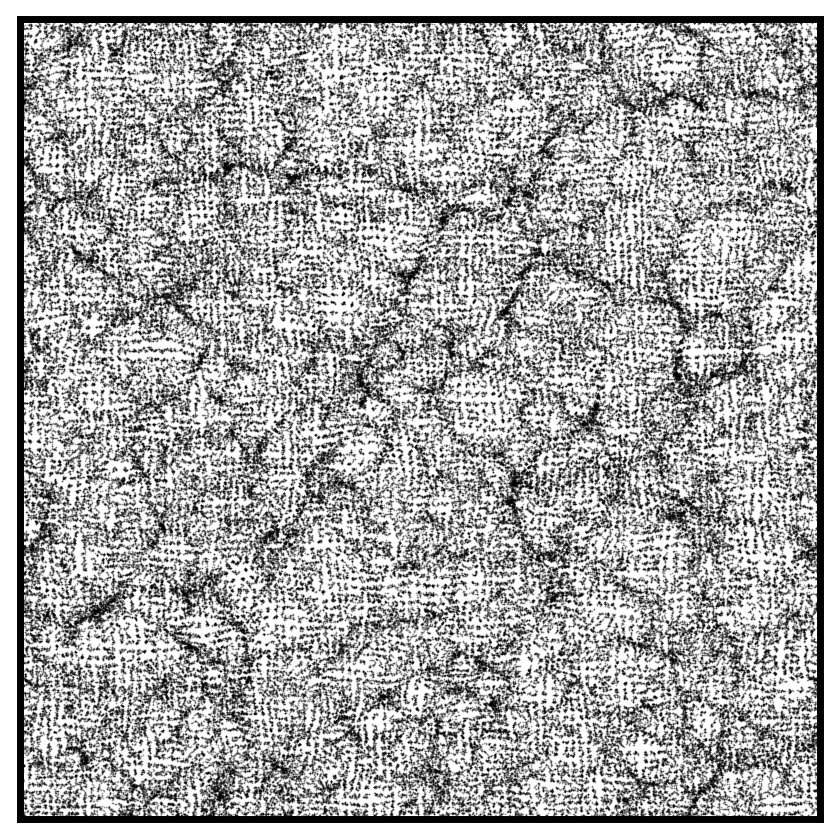

In [15]:
# ZA particles — full box
fig = plot_particle_scatter(x_za, y_za)
save_figure(fig, "fig1_za_particle_positions")
plt.show()


## Map2map particles: $x = q + \Psi(q)$ (full box)


Loading map2map displacement slab…
map2map particles: (512, 512, 20)
Saved: /home/kstoreyf/muchisimocks/figures/2026-09-03_figure1/figure1/fig1_particle_positions.png
Saved: /home/kstoreyf/muchisimocks/figures/paper_figures_latest/figure1/fig1_particle_positions.png


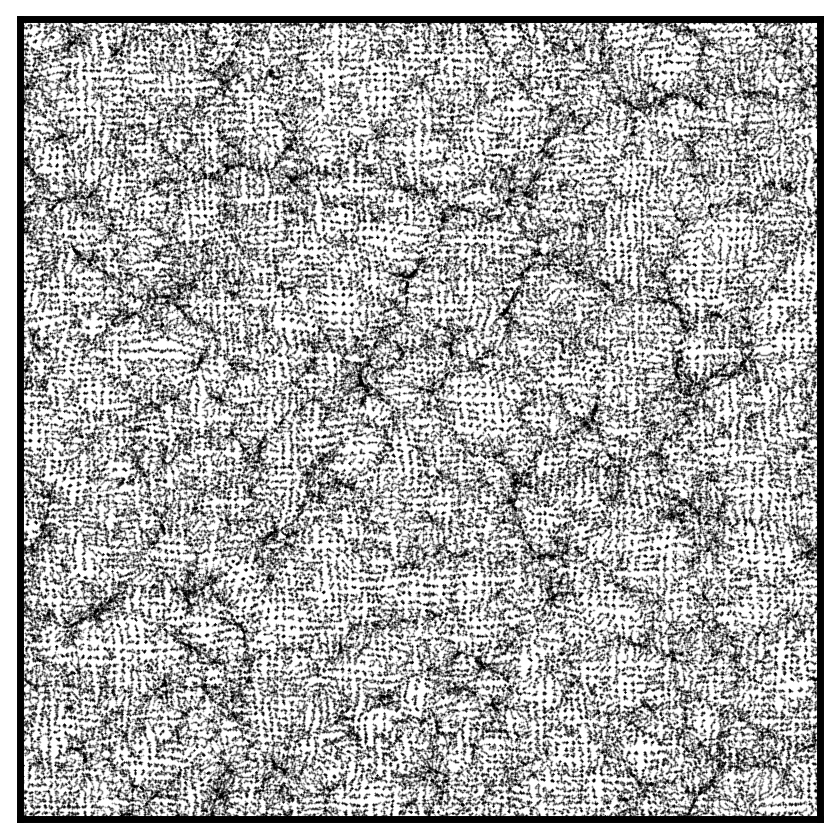

In [16]:
print("Loading map2map displacement slab…")
disp_pred = load_disp_slab(FN_DISP)
x_p, y_p, z_p = displace_slab(disp_pred)
print("map2map particles:", x_p.shape)

# map2map particles — full box
fig = plot_particle_scatter(x_p, y_p)
save_figure(fig, "fig1_particle_positions")
plt.show()


## Bias operators (128³), stacked

Eulerian bias fields after the \(k\)-cut to \(128^3\) (`bias_fields_eul_deconvolved`). Front → back: \(1\), \(\delta\), \(\delta^2\), \(s^2\), \(\nabla^2\delta\).


Bias fields: /data/kstoreyf/muchisimocks/muchisimocks_lib_p5_n10000_rerun/LH0/bias_fields_eul_deconvolved_0.npy exists= True
Bias slice: 20 cells ≈ 156.2 Mpc/h (cell=7.81)
loaded (5, 128, 128, 128)


/tmp/ipykernel_920370/4012686373.py:105: UserWarning: Glyph 108 (l) missing from font(s) dsrom10.
  fig.savefig(
/tmp/ipykernel_920370/4012686373.py:105: UserWarning: Glyph 112 (p) missing from font(s) dsrom10.
  fig.savefig(


Saved: /home/kstoreyf/muchisimocks/figures/2026-09-03_figure1/figure1/fig1_bias_fields_stack.png
Saved: /home/kstoreyf/muchisimocks/figures/paper_figures_latest/figure1/fig1_bias_fields_stack.png


/home/kstoreyf/.conda/envs/benv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) dsrom10.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kstoreyf/.conda/envs/benv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) dsrom10.
  fig.canvas.print_figure(bytes_io, **kw)


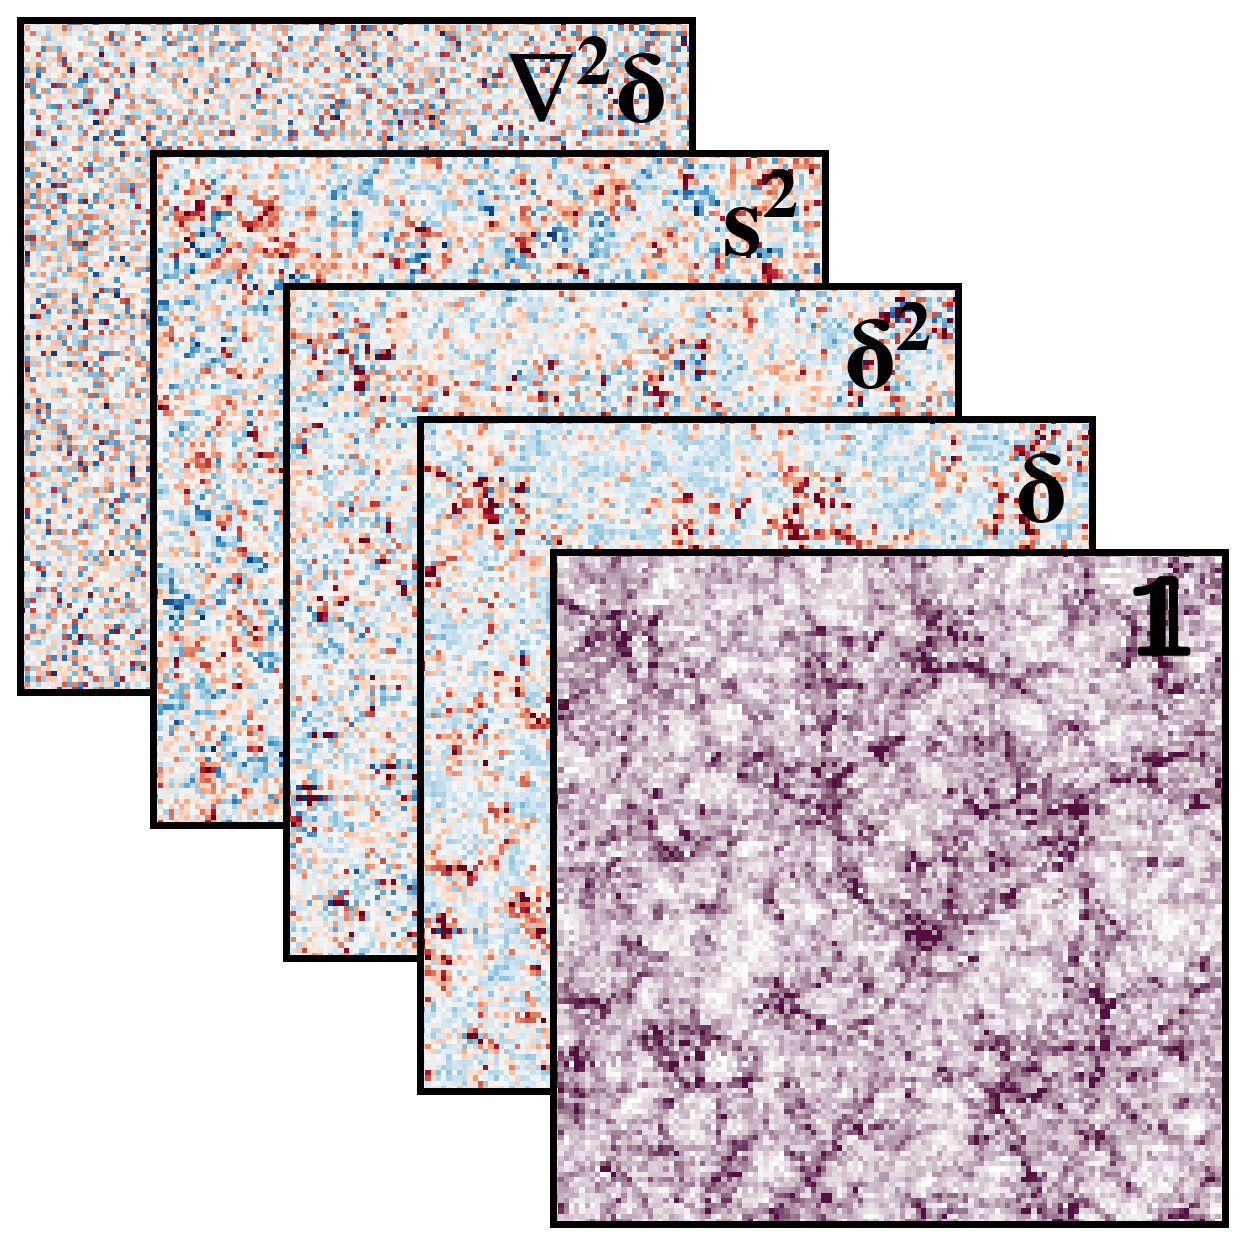

In [17]:
FN_BFIELDS = DIR_LH / f"bias_fields_eul_deconvolved_{DIR_LH.name.replace('LH', '')}.npy"
if not FN_BFIELDS.is_file():
    FN_BFIELDS = DIR_LH / "bias_fields_eul_deconvolved_0.npy"
print("Bias fields:", FN_BFIELDS, "exists=", FN_BFIELDS.is_file())

# True \mathds{1} from the dsfont (doublestroke) Type1 font — matplotlib mathtext
# cannot \usepackage{dsfont}, so load dsrom10.pfb directly. Fake-bold via stroke.
from matplotlib.font_manager import FontProperties
import matplotlib.patheffects as pe
MATHDS_ONE_FONT = FontProperties(
    fname=str(REPO_ROOT / "data" / "fonts" / "dsrom10.pfb"),
    size=40,
)

BIAS_LABELS = [
    "1",  # rendered as bold \mathds{1} via MATHDS_ONE_FONT
    r"$\mathbf{\delta}$",
    r"$\mathbf{\delta^{2}}$",
    r"$\mathbf{s^{2}}$",
    r"$\mathbf{\nabla^{2}\delta}$",
]
# Draw back-to-front so the 1-field sits on top (matches the reference stack).
STACK_ORDER = [4, 3, 2, 1, 0]

N_GRID_BIAS = 128
CELL_BIAS = BOX_SIZE / N_GRID_BIAS
N_SLICE_BIAS = 20  # cells along z for 128³ bias / noise / tracer projections
print(f"Bias slice: {N_SLICE_BIAS} cells ≈ {N_SLICE_BIAS * CELL_BIAS:.1f} Mpc/h (cell={CELL_BIAS:.2f})")


def plot_bias_field_stack(fields_2d, labels, stack_order=STACK_ORDER):
    """Diagonal card-stack of square panels; black frames, no ticks."""
    plt.rcParams["mathtext.fontset"] = "stix"  # \mathbf bold-ifies Greek too
    n = len(stack_order)
    fig_w, fig_h = 7.4, 7.0
    fig = plt.figure(figsize=(fig_w, fig_h), dpi=DPI, facecolor="none")

    panel = 0.48
    dx, dy = 0.09, 0.095
    # Extra margin so front-card bottom/right spines aren't clipped by tight bbox.
    left0, bot0 = 0.05, 0.08
    # i=0 (back) top-left; i=n-1 (front) bottom-right
    for i, idx in enumerate(stack_order):
        left = left0 + i * dx
        bottom = bot0 + (n - 1 - i) * dy
        ax = fig.add_axes([left, bottom, panel, panel])
        ax.set_facecolor("none")
        img = fields_2d[idx]
        if idx == 0:
            vmax = np.percentile(img, 98)
            vmin = np.percentile(img, 2)
            cmap = CMAP_DENSITY
        else:
            vmax = 3 * np.std(img)
            vmin = -vmax
            cmap = "RdBu_r"
        ax.imshow(
            img,
            origin="lower",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest",
            aspect="equal",
        )
        style_axes(ax)
        for spine in ax.spines.values():
            spine.set_clip_on(False)
        # Symbol in the visible upper-right corner of each card.
        if idx == 0:
            ax.text(
                0.96,
                0.96,
                labels[idx],
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontproperties=MATHDS_ONE_FONT,
                color="black",
                path_effects=[pe.withStroke(linewidth=2.0, foreground="black")],
            )
        else:
            ax.text(
                0.96,
                0.96,
                labels[idx],
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=36,
                fontweight="bold",
                color="black",
            )
    return fig


bfields = np.load(FN_BFIELDS, mmap_mode="r")
print("loaded", bfields.shape)
bfields_2d = [project_slice(bfields[i], n_slice=N_SLICE_BIAS) for i in range(bfields.shape[0])]

fig = plot_bias_field_stack(bfields_2d, BIAS_LABELS)
filename = f"fig1_bias_fields_stack.{FIG_EXT}"
for path in (FIG_DIR / filename, FIG_DIR_LATEST / filename):
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(
        path,
        bbox_inches="tight",
        pad_inches=0.08,
        facecolor="none",
        edgecolor="none",
        dpi=DPI,
    )
    print(f"Saved: {path}")
plt.show()


## Noise and tracer field

**Operator-coupled** noise and the **combined tracer** from `utils_model.get_tracer_field`, using the first nested-LH bias+noise row for this cosmology (`biasnoisenest_p9_n320000`, `idx_cosmo=0`). Coupled noise is signed (RdBu); tracer uses Blues.


First nested-LH row for LH0:
b1            2.234800
b2           -0.642592
bs2          -0.013598
bl            7.606026
An_homog      0.085215
An_b1        -1.539890
An_b2         0.485008
An_bs2       -3.687469
An_bl        -7.533955
idx_cosmo     0.000000
nest_layer    0.000000
bias_vector [2.2348004205277068, -0.6425915007971321, -0.0135978036462081, 7.606026447919444]
A_noise [0.0852146823187345, -1.539890347543659, 0.4850084822256137, -3.6874692638278153, -7.533955009972836]
Noise field: /scratch/kstoreyf/muchisimocks/data/noise_fields/fields_noise_unit_p5_n10000/noise_field_n0.npy
noise shape (128, 128, 128)
bias fields (5, 128, 128, 128)
slice cells 20
std coupled/tracer 2.425973785668222e-07 6.420916173971777e-07
Saved: /home/kstoreyf/muchisimocks/figures/2026-09-03_figure1/figure1/fig1_noise_field_coupled.png
Saved: /home/kstoreyf/muchisimocks/figures/paper_figures_latest/figure1/fig1_noise_field_coupled.png


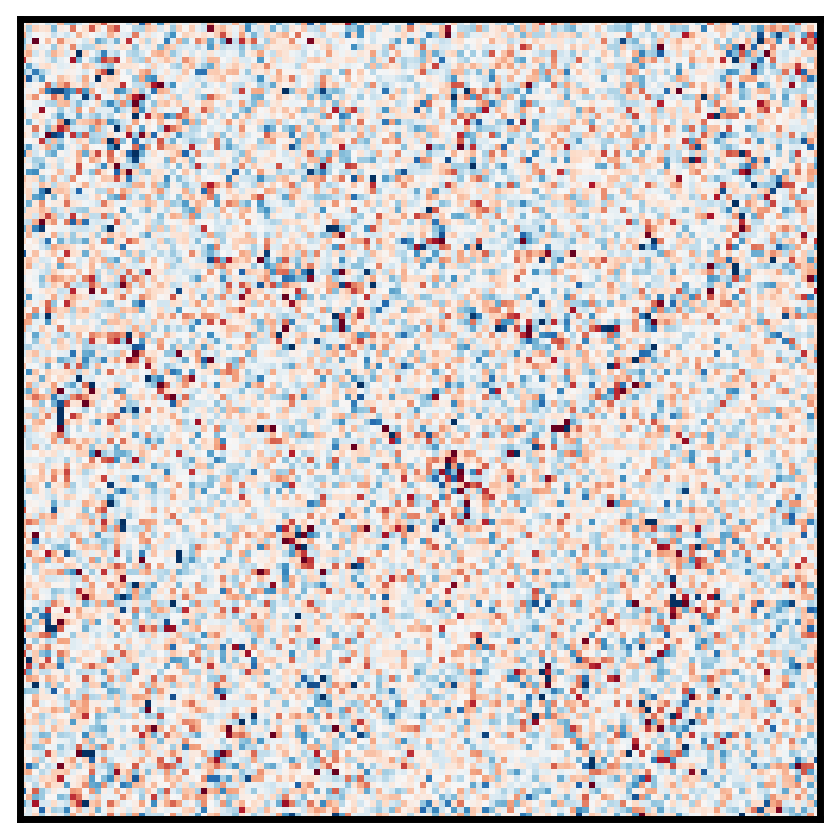

Saved: /home/kstoreyf/muchisimocks/figures/2026-09-03_figure1/figure1/fig1_tracer_field.png
Saved: /home/kstoreyf/muchisimocks/figures/paper_figures_latest/figure1/fig1_tracer_field.png


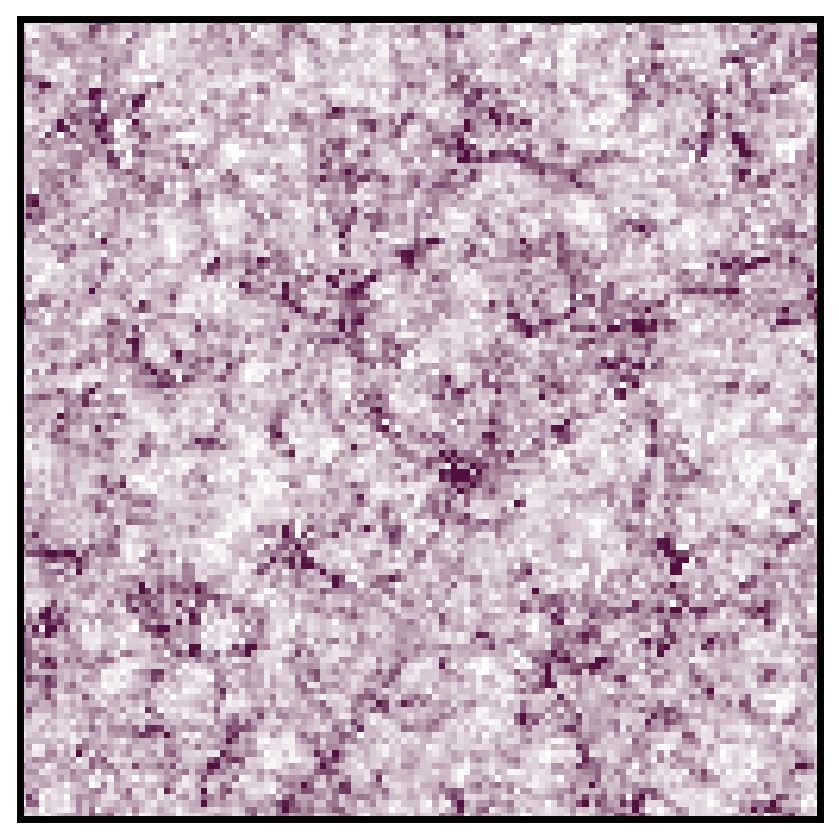

In [18]:
import data_loader
import utils_model

TAG_BIASPARAMS = "_biasnoisenest_p9_n320000"
TAG_NOISE = "_noise_unit_p5_n10000"
N_GRID_ORIG = 512
IDX_NOISE = 0  # matches LH0 (idx_mock)

biasparams_df, biasparams_dict_fixed = data_loader.load_bias_params(TAG_BIASPARAMS, bx=32)
row0 = biasparams_df[biasparams_df["idx_cosmo"] == 0].iloc[0]
idx_bias = row0.name
print("First nested-LH row for LH0:")
print(row0.to_string())

bias_vector = [float(row0[n]) for n in utils_model.biasparam_names_ordered]
A_noise = [float(row0[n]) for n in utils_model.noiseparam_names_ordered]
print("bias_vector", bias_vector)
print("A_noise", A_noise)

fn_noise = paths.noise_fields_dir(TAG_NOISE) / f"noise_field_n{IDX_NOISE}.npy"
print("Noise field:", fn_noise)
noise_field = np.load(fn_noise)
print("noise shape", noise_field.shape)

if "bfields" not in dir() or bfields.shape[-1] != noise_field.shape[-1]:
    bfields = np.load(FN_BFIELDS)
print("bias fields", bfields.shape)

# Coupled noise only (same as get_tracer_field multiplicative branch)
noise_coupled = np.sum(
    [bfields[ii] * A_noise[ii] * noise_field for ii in range(len(bfields))],
    axis=0,
) / N_GRID_ORIG**3

tracer_field = utils_model.get_tracer_field(
    bfields,
    bias_vector,
    N_GRID_ORIG,
    noise_field=noise_field,
    A_noise=A_noise,
    noise_model="multiplicative",
)

n_slice_b = N_SLICE_BIAS
coupled_2d = project_slice(noise_coupled, n_slice=n_slice_b)
tracer_2d = project_slice(tracer_field, n_slice=n_slice_b)
print("slice cells", n_slice_b)
print("std coupled/tracer", float(np.std(coupled_2d)), float(np.std(tracer_2d)))

fig = plot_field_panel(coupled_2d, diverging=True)
save_figure(fig, "fig1_noise_field_coupled")
plt.show()

fig = plot_field_panel(tracer_2d)
save_figure(fig, "fig1_tracer_field")
plt.show()


## SHAMe OOD mock ($\bar n = 2.2\times10^{-4}$)

- **Scatter** (`fig1_shame_particle_positions`): catalog galaxies, **full xy** + thick z-slice.
- **Field** (`fig1_shame_tracer_field`): CIC+$k$-cut tracer on the 132³ grid — **full xy** (z-slice only).


SHAMe catalog: /home/kstoreyf/muchisimocks/data/shame_catalogues_to_share/kate/kate_sham_catalogue_a1.0_par_b_Planck_N3072_L1024_0.00_0.00022.h5 exists= True
SHAMe tracer: /home/kstoreyf/muchisimocks/data/data_shame/data_nbar0.00022/tracer_field_phase0.npy exists= True
gal_pos (236223, 3) nbar= 0.00021999981254339218
SHAMe scatter slice width ≈ 310.3 Mpc/h (40 cells on 132³)
Saved: /home/kstoreyf/muchisimocks/figures/2026-09-03_figure1/figure1/fig1_shame_particle_positions.png
Saved: /home/kstoreyf/muchisimocks/figures/paper_figures_latest/figure1/fig1_shame_particle_positions.png


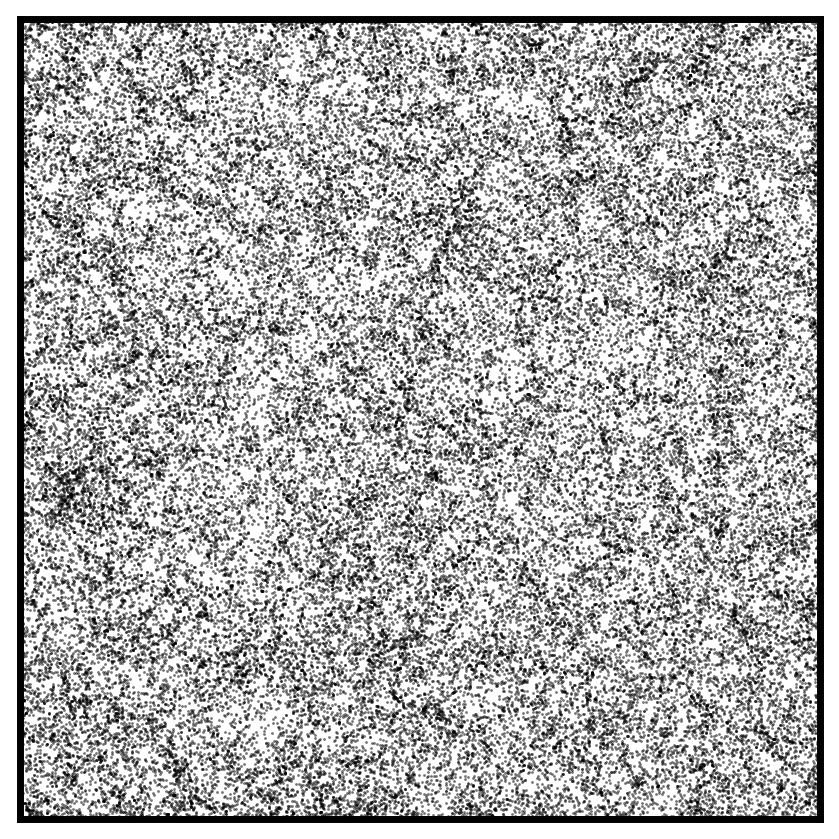

shame tracer (132, 132, 132) std= 1.755271574570653e-06
Saved: /home/kstoreyf/muchisimocks/figures/2026-09-03_figure1/figure1/fig1_shame_tracer_field.png
Saved: /home/kstoreyf/muchisimocks/figures/paper_figures_latest/figure1/fig1_shame_tracer_field.png


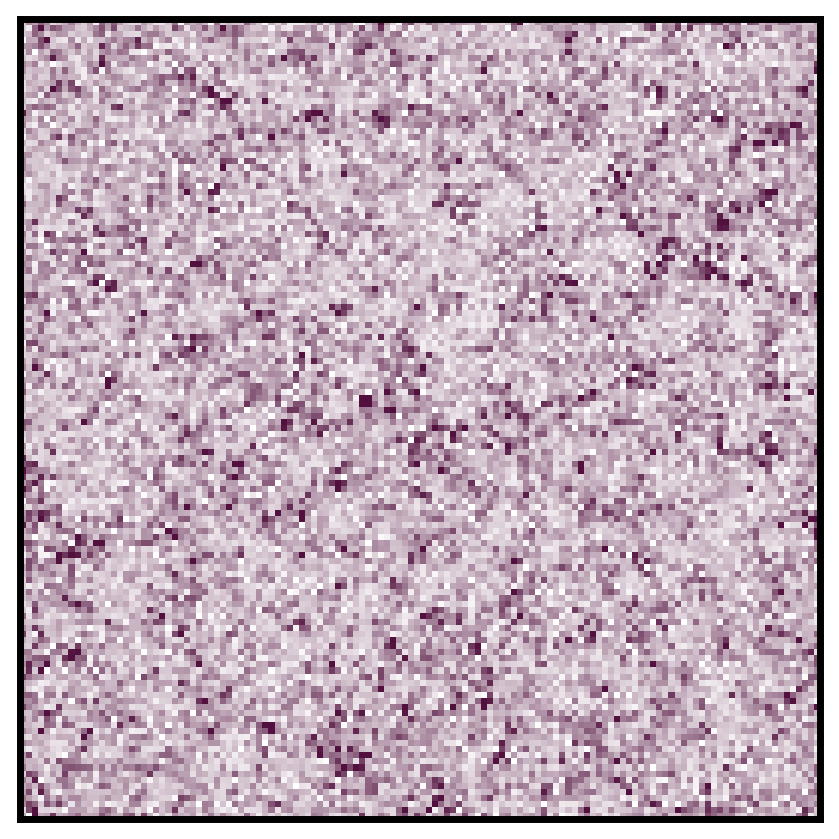

In [19]:
import h5py

TAG_MOCK_SHAME = "_nbar0.00022"
NBAR_SHAME = "0.00022"  # catalog filename uses nbar without the "nbar" prefix
BOX_SIZE_SHAME = 1024.0
FN_SHAME_CAT = (
    REPO_ROOT
    / "data"
    / "shame_catalogues_to_share"
    / "kate"
    / f"kate_sham_catalogue_a1.0_par_b_Planck_N3072_L1024_0.00_{NBAR_SHAME}.h5"
)
FN_SHAME_TRACER = (
    REPO_ROOT / "data" / "data_shame" / f"data{TAG_MOCK_SHAME}" / "tracer_field_phase0.npy"
)
print("SHAMe catalog:", FN_SHAME_CAT, "exists=", FN_SHAME_CAT.is_file())
print("SHAMe tracer:", FN_SHAME_TRACER, "exists=", FN_SHAME_TRACER.is_file())

with h5py.File(FN_SHAME_CAT, "r") as cat:
    gal_pos = cat["gal_pos"][:]
print("gal_pos", gal_pos.shape, "nbar=", gal_pos.shape[0] / BOX_SIZE_SHAME**3)

# Thicker z-slice for the catalog scatter (40 cells on the 132³-equivalent grid)
CELL_SHAME_128ISH = BOX_SIZE_SHAME / 132
N_SLICE_SHAME_SCATTER = 40
Z_WIDTH_SHAME = N_SLICE_SHAME_SCATTER * CELL_SHAME_128ISH
print(f"SHAMe scatter slice width ≈ {Z_WIDTH_SHAME:.1f} Mpc/h ({N_SLICE_SHAME_SCATTER} cells on 132³)")

# SHAMe scatter: full xy + z-slice
fig = plot_catalog_scatter(
    gal_pos, BOX_SIZE_SHAME, z0=0.0, z_width=Z_WIDTH_SHAME, s=1.0, color="black",
)
save_figure(fig, "fig1_shame_particle_positions")
plt.show()

shame_tracer = np.load(FN_SHAME_TRACER)
print("shame tracer", shame_tracer.shape, "std=", float(np.std(shame_tracer)))
n_slice_shame = N_SLICE_BIAS  # 20 cells on 132³
# SHAMe field: full xy (project_slice averages in z only)
shame_2d = project_slice(shame_tracer, n_slice=n_slice_shame)
fig = plot_field_panel(shame_2d)  # density purple, same as muchisimocks tracer
save_figure(fig, "fig1_shame_tracer_field")
plt.show()


## Training-set tracers: cosmologies × bias params

A portion of the noisy training set (`_p5_n10000` × `_biasnoisenest_p9_n320000`).

- **3 stacks** = first 3 cosmologies (`LH0`–`LH2`), **1 row × 3 cols**
- **8 cards per stack** = that cosmology's first 8 nested bias+noise draws (all distinct)
- Stacks packed close together (overlapping card stacks, small gutters between stacks)
- Each card is the projected tracer field (same z-slice depth as other 128³ panels)


bias params: (320000, 11)
LH0: param idxs=[0, 10000, 20000, 30000, 40000, 50000, 60000, 70000]  b1=[+2.23, +1.06, +1.82, -0.02, +0.53, +0.93, -0.83, +1.88]
LH1: param idxs=[1, 10001, 20001, 30001, 40001, 50001, 60001, 70001]  b1=[+2.53, -0.37, +0.71, +1.69, -0.40, +2.86, -0.28, +2.16]
LH2: param idxs=[2, 10002, 20002, 30002, 40002, 50002, 60002, 70002]  b1=[-0.64, +2.46, +1.58, +0.02, +0.98, +1.99, +2.00, +1.75]
OK: 24 distinct bias+noise parameter rows
cascade: dx=0.0180 dy=0.0514 (inches: 0.216 right, 0.216 down); panel inches=2.160; pitch_x=0.22
Saved: /home/kstoreyf/muchisimocks/figures/2026-09-03_figure1/figure1/fig1_training_set_stacks.png
Saved: /home/kstoreyf/muchisimocks/figures/paper_figures_latest/figure1/fig1_training_set_stacks.png


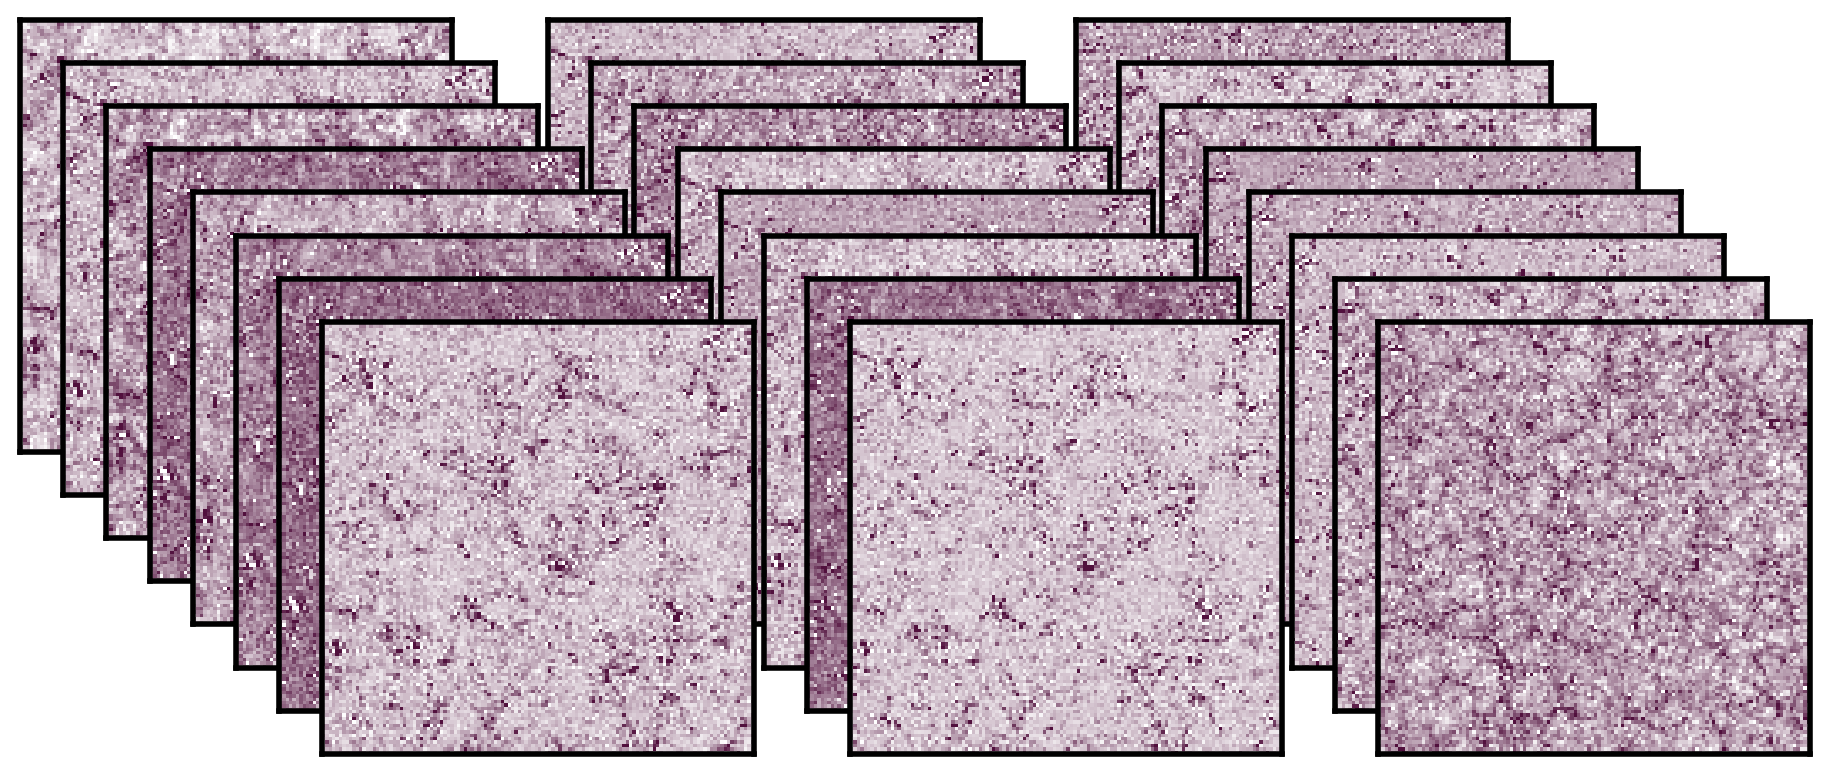

In [32]:
import data_loader
import utils_model

# --- layout: 3 cosmologies × 8 bias params, 1 row × 3 cols ---
N_STACKS = 3
N_CARDS = 8
N_COLS = 3
COSMO_IDXS = [0, 1, 2]  # must match N_STACKS (one stack per cosmo)
# Hand-tuned z-order for the 1×3 row (L→R); higher draws on top when stacks overlap.
STACK_ZORDER = [[2, 1, 0]]

TAG_BIASPARAMS_TRAIN = "_biasnoisenest_p9_n320000"
TAG_NOISE_TRAIN = "_noise_unit_p5_n10000"
DIR_LIB_TRAIN = Path("/data/kstoreyf/muchisimocks/muchisimocks_lib_p5_n10000")
N_GRID_ORIG = 512
n_slice_bias = N_SLICE_BIAS if "N_SLICE_BIAS" in dir() else 20

assert len(COSMO_IDXS) == N_STACKS, f"COSMO_IDXS ({len(COSMO_IDXS)}) must equal N_STACKS ({N_STACKS})"

biasparams_df_train, _ = data_loader.load_bias_params(TAG_BIASPARAMS_TRAIN, bx=32)
print("bias params:", biasparams_df_train.shape)


def bias_rows_for_cosmo(df, idx_cosmo, n_cards=N_CARDS):
    """First n_cards nested bias+noise rows for this cosmology (table order)."""
    sub = df[df["idx_cosmo"] == idx_cosmo].sort_index()
    if len(sub) < n_cards:
        raise ValueError(f"Only {len(sub)} bias rows for cosmo {idx_cosmo}")
    return sub.iloc[:n_cards]


def load_train_tracer_2d(idx_cosmo, row, n_slice=n_slice_bias):
    """Build one noisy training tracer and project a z-slice."""
    fn_bf = DIR_LIB_TRAIN / f"LH{idx_cosmo}" / f"bias_fields_eul_deconvolved_{idx_cosmo}.npy"
    bfields = np.load(fn_bf)
    fn_noise = paths.noise_fields_dir(TAG_NOISE_TRAIN) / f"noise_field_n{idx_cosmo}.npy"
    noise_field = np.load(fn_noise)
    bias_vector = [float(row[n]) for n in utils_model.biasparam_names_ordered]
    A_noise = [float(row[n]) for n in utils_model.noiseparam_names_ordered]
    tracer = utils_model.get_tracer_field(
        bfields,
        bias_vector,
        N_GRID_ORIG,
        noise_field=noise_field,
        A_noise=A_noise,
        noise_model="multiplicative",
    )
    return project_slice(tracer, n_slice=n_slice)


# Build stacks: list[cosmo] of list[card] (back→front = first→last nest row)
stacks_2d = []
seen_param_idxs = []
for idx_c in COSMO_IDXS:
    rows = bias_rows_for_cosmo(biasparams_df_train, idx_c, N_CARDS)
    seen_param_idxs.extend(rows.index.tolist())
    print(
        f"LH{idx_c}: param idxs={rows.index.tolist()}  b1=["
        + ", ".join(f"{float(b):+.2f}" for b in rows["b1"].values)
        + "]"
    )
    cards = [load_train_tracer_2d(idx_c, row) for _, row in rows.iterrows()]
    stacks_2d.append(cards)

assert len(seen_param_idxs) == len(set(seen_param_idxs)), "bias/noise rows must all be distinct"
print(f"OK: {len(seen_param_idxs)} distinct bias+noise parameter rows")


def plot_training_set_stacks(
    stacks,
    n_cols=N_COLS,
    # Card size in figure-fraction WIDTH. Height is set so cards are square in inches.
    panel=0.22,
    # Within-stack cascade: `dx` is figure-fraction RIGHT shift.
    # `dy` is matched so the DOWN shift equals `dx` in inches (see note below).
    dx=0.024,
    dy=None,  # None → equal physical step; set explicitly only if you want uneven cascade
    # Spacing between stack origins (figure fraction). pitch_x should be > panel for clear separation.
    stack_pitch_x=0.12,
    stack_pitch_y=0.15,
    left0=0.02,
    bot0=0.02,
    # Hand-tuned z-order of stacks (row-major). Higher draws on top when stacks overlap.
    # Within a stack, later cards still sit above earlier ones.
    stack_zorder=None,
    spine_lw=2.0,
):
    """Diagonal card-stacks; each stack = one cosmology, cards = bias draws.

    What controls the cascade slant
    --------------------------------
    - `dx`, `dy`: per-card shift in **figure coordinates** (0–1 of the figure).
      On a non-square figure, equal dx/dy look uneven in inches because
      1 unit horizontally ≠ 1 unit vertically. We auto-set
          dy = dx * (fig_w / fig_h)
      so the physical right/down steps match (unless you pass `dy` yourself).
    - `panel`: card width in figure fraction; height is auto-squared in inches.
    - `stack_pitch_x` / `stack_pitch_y`: spacing between stack origins.
    """
    n_stacks = len(stacks)
    n_rows = int(np.ceil(n_stacks / n_cols))
    n_cards = max(len(c) for c in stacks)
    if stack_zorder is None:
        stack_zorder = [[r * n_cols + c for c in range(n_cols)] for r in range(n_rows)]
    stack_zorder = np.asarray(stack_zorder)
    assert stack_zorder.shape == (n_rows, n_cols), (
        f"stack_zorder shape {stack_zorder.shape} != ({n_rows}, {n_cols})"
    )

    # Wide enough for n_cols separated stacks
    fig_w = 12.0 if n_rows == 1 else 7.2
    fig_h = 4.2 if n_rows == 1 else 7.2
    fig = plt.figure(figsize=(fig_w, fig_h), dpi=DPI, facecolor="none")

    # Square cards in inches: panel_w * fig_w == panel_h * fig_h
    panel_w = panel
    panel_h = panel * fig_w / fig_h
    # Equal physical cascade (unless dy overridden)
    dx_use = dx
    dy_use = dy if dy is not None else dx * fig_w / fig_h
    print(
        f"cascade: dx={dx_use:.4f} dy={dy_use:.4f} "
        f"(inches: {dx_use*fig_w:.3f} right, {dy_use*fig_h:.3f} down); "
        f"panel inches={panel_w*fig_w:.3f}; pitch_x={stack_pitch_x}"
    )

    for s, cards in enumerate(stacks):
        col = s % n_cols
        row = s // n_cols
        origin_left = left0 + col * stack_pitch_x
        origin_bot = bot0 + (n_rows - 1 - row) * stack_pitch_y
        z_stack = int(stack_zorder[row, col])
        n = len(cards)
        for i, img in enumerate(cards):  # i=0 back … i=n-1 front
            left = origin_left + i * dx_use
            bottom = origin_bot + (n - 1 - i) * dy_use
            ax = fig.add_axes([left, bottom, panel_w, panel_h])
            z = z_stack * (n_cards + 1) + i
            ax.set_zorder(z)
            # White face so any subpixel edge isn't a thick black (transparent) strip
            ax.set_facecolor("white")
            ax.patch.set_zorder(z)
            vmax = np.percentile(img, 99)
            vmin = 0.0 if np.nanmin(img) >= 0 else np.percentile(img, 1)
            # aspect='auto': image fills the (already square-in-inches) axes — no letterbox margins
            ax.imshow(
                img,
                origin="lower",
                cmap=CMAP_DENSITY,
                vmin=vmin,
                vmax=vmax,
                interpolation="nearest",
                aspect="auto",
                zorder=z,
                extent=(0, 1, 0, 1),
                rasterized=True,
            )
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            # Uniform hairline frame (image is rasterized; spines stay crisp & equal width)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.tick_params(length=0, labelbottom=False, labelleft=False)
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_color("black")
                spine.set_linewidth(spine_lw)
                spine.set_zorder(z + 0.1)
                spine.set_clip_on(True)
    return fig


# pitch_x must exceed panel + (n_cards-1)*dx so cascade overhangs don't overlap
# neighboring stacks (overlapping spines read as "thick borders").
fig = plot_training_set_stacks(
    stacks_2d, stack_zorder=STACK_ZORDER,
    # closer stacks (lower pitch_x); larger dx → more of each card peeks in the cascade
    panel=0.18, dx=0.018, stack_pitch_x=0.22, stack_pitch_y=0.12,
)
filename = f"fig1_training_set_stacks.{FIG_EXT}"
for path in (FIG_DIR / filename, FIG_DIR_LATEST / filename):
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(
        path,
        bbox_inches="tight",
        pad_inches=0.06,
        facecolor="none",
        edgecolor="none",
        dpi=DPI,
    )
    print(f"Saved: {path}")
plt.show()


## Training-set $P(k)$ ranges

Same bands as Fig. 2 (median, 16–84%, 1–99%) in `#79D0EC`. White axes face, L-shaped spines only, ~5:3 panel; no labels.


dir_statistics: /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Found 10000 diff cosmo pks in /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Subsampled to 100 cosmologies (n_cosmo_max=100)
training pks (3200, 32) k (32,)
PK_XLIM (0.010593321675582556, 0.3775963745011735) PK_YLIM (4210.389403584742, 833622.0601753553)
Saved: /home/kstoreyf/muchisimocks/figures/2026-09-03_figure1/figure1/fig1_training_pk_ranges.png
Saved: /home/kstoreyf/muchisimocks/figures/paper_figures_latest/figure1/fig1_training_pk_ranges.png


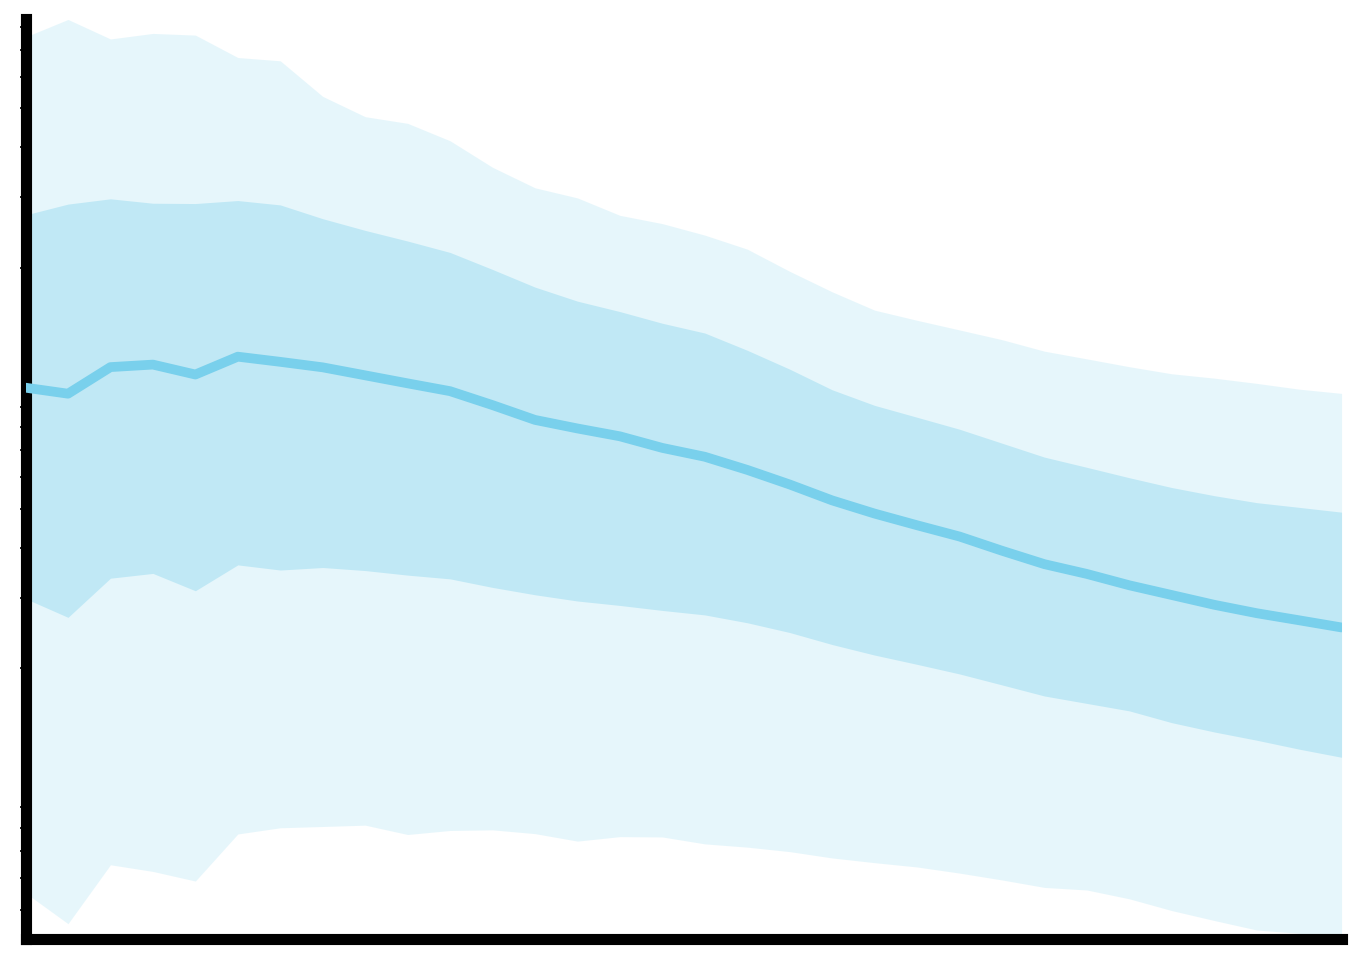

In [29]:
import data_loader

# Fig. 2 tags / color for P(k)
TAG_PARAMS_PK = "_p5_n10000"
TAG_BIASPARAMS_PK = "_biasnoisenest_p9_n320000"
TAG_NOISE_PK = "_noise_unit_p5_n10000"
BX_PK = 32
N_COSMO_MAX_STATS = 100  # same subsample as Fig. 2 (seed=42 inside loader)
COLOR_PK_TRAIN = "#79D0EC"
LW_PK = 3.5
SPINE_LW_PK = 4.0
FIGSIZE_PK = (7.0, 5.0)  # 7:4, shared with SHAMe P(k) panel

k_pk, pks, _, _ = data_loader.load_data_muchisimocks(
    "pk",
    TAG_PARAMS_PK,
    TAG_BIASPARAMS_PK,
    tag_noise=TAG_NOISE_PK,
    bx=BX_PK,
    n_cosmo_max=N_COSMO_MAX_STATS,
)
median = np.nanmedian(pks, axis=0)
p1 = np.nanpercentile(pks, 1, axis=0)
p16 = np.nanpercentile(pks, 16, axis=0)
p84 = np.nanpercentile(pks, 84, axis=0)
p99 = np.nanpercentile(pks, 99, axis=0)
print("training pks", pks.shape, "k", k_pk.shape)

# Shared with SHAMe panel so both sit on the same y-scale
PK_XLIM = (float(np.nanmin(k_pk)), float(np.nanmax(k_pk)))
PK_YLIM = (float(np.nanmin(p1)), float(np.nanmax(p99)))
print("PK_XLIM", PK_XLIM, "PK_YLIM", PK_YLIM)


def style_pk_axes(ax, xlim, ylim, lw=SPINE_LW_PK):
    """White interior, transparent figure pad; only left+bottom spines; no labels/ticks."""
    ax.set_facecolor("white")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(length=0, labelbottom=False, labelleft=False)
    for side, spine in ax.spines.items():
        if side in ("left", "bottom"):
            spine.set_visible(True)
            spine.set_color("black")
            spine.set_linewidth(lw)
            spine.set_clip_on(False)
        else:
            spine.set_visible(False)


fig = plt.figure(figsize=FIGSIZE_PK, dpi=DPI, facecolor="none")
ax = fig.add_axes([0.03, 0.05, 0.94, 0.92])
ax.fill_between(k_pk, p1, p99, color=COLOR_PK_TRAIN, alpha=0.18, zorder=1, linewidth=0)
ax.fill_between(k_pk, p16, p84, color=COLOR_PK_TRAIN, alpha=0.35, zorder=2, linewidth=0)
ax.plot(k_pk, median, color=COLOR_PK_TRAIN, lw=LW_PK, solid_capstyle="round", zorder=3)
style_pk_axes(ax, PK_XLIM, PK_YLIM)
save_figure(fig, "fig1_training_pk_ranges")
plt.show()


## SHAMe $P(k)$ (fiducial $\bar n$)

Fiducial SHAMe mock only (`_nbar0.00022`), same mid-grey as Fig. 2 (`"0.42"`), dashed. Same 5:3 L-axes style as the training $P(k)$ panel.


shame pk (32,) k (32,) from /home/kstoreyf/muchisimocks/data/data_shame/data_nbar0.00022/pks/pk.npy
using training PK_YLIM (4210.389403584742, 833622.0601753553)
(4210.389403584742, 166724.41203507106)
Saved: /home/kstoreyf/muchisimocks/figures/2026-09-03_figure1/figure1/fig1_shame_pk.png
Saved: /home/kstoreyf/muchisimocks/figures/paper_figures_latest/figure1/fig1_shame_pk.png


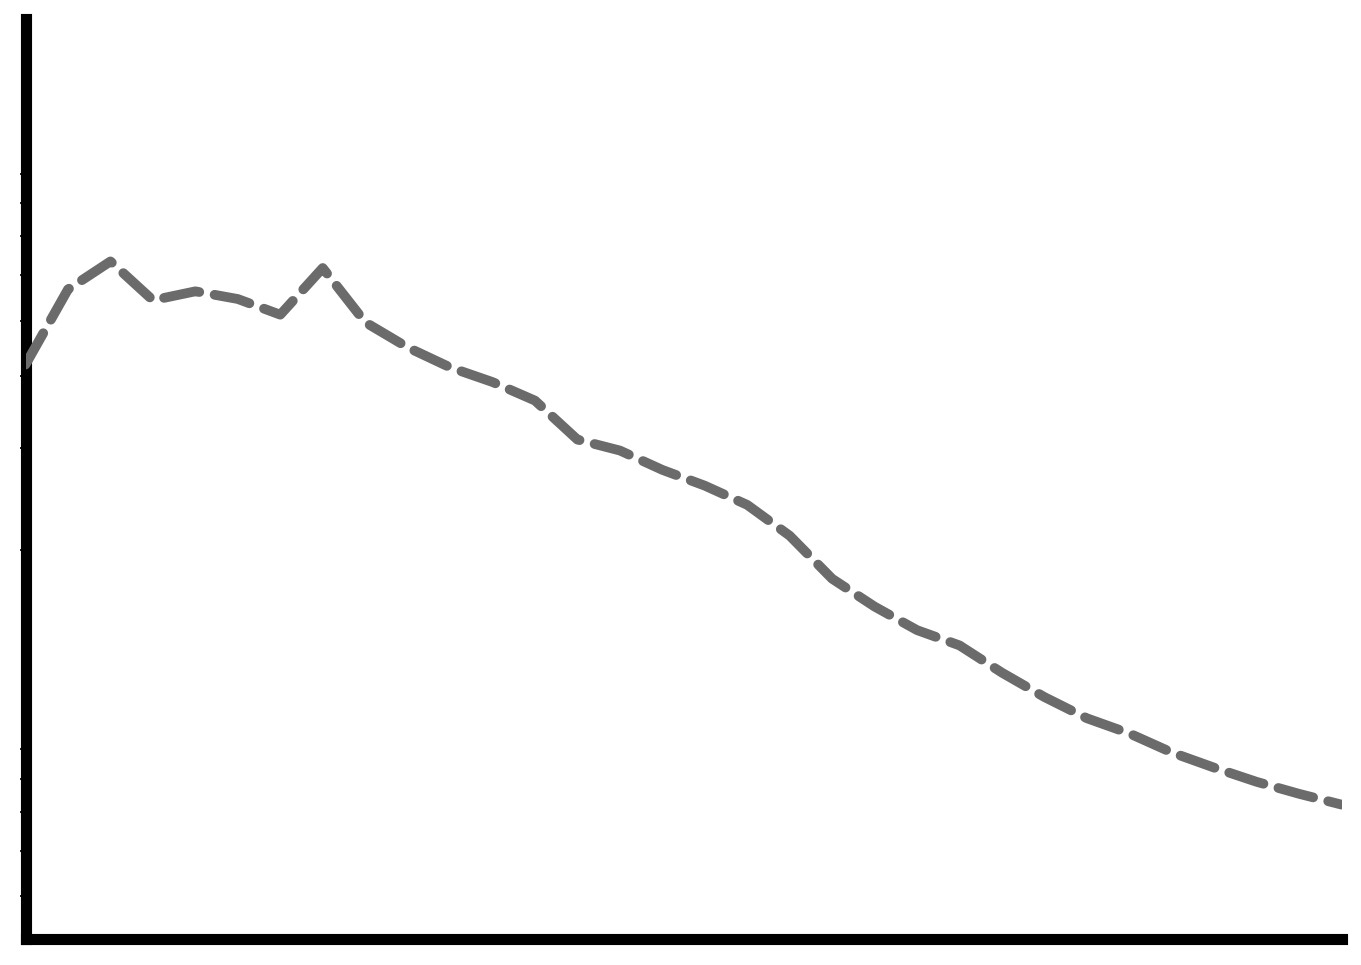

In [42]:
# Fiducial SHAMe P(k) — Fig. 2 color for nbar=2.2e-4
# Requires PK_XLIM / PK_YLIM from the training P(k) cell (same y-scale).
TAG_MOCK_SHAME_PK = "_nbar0.00022"
COLOR_PK_SHAME = "0.42"
LW_PK_SHAME = 3.5
SPINE_LW_PK = 4.0
FIGSIZE_PK = (7.0, 5.0)  # match training P(k) panel

fn_shame_pk = REPO_ROOT / "data" / "data_shame" / f"data{TAG_MOCK_SHAME_PK}" / "pks" / "pk.npy"
k_pk_shame, pk_shame, _, _ = data_loader.load_pk(fn_shame_pk)
print("shame pk", np.shape(pk_shame), "k", np.shape(k_pk_shame), "from", fn_shame_pk)
print("using training PK_YLIM", PK_YLIM)


def style_pk_axes(ax, xlim, ylim, lw=SPINE_LW_PK):
    """White interior, transparent figure pad; only left+bottom spines; no labels/ticks."""
    ax.set_facecolor("white")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(*xlim)
    print(ylim)
    ax.set_ylim(*ylim)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(length=0, labelbottom=False, labelleft=False)
    for side, spine in ax.spines.items():
        if side in ("left", "bottom"):
            spine.set_visible(True)
            spine.set_color("black")
            spine.set_linewidth(lw)
            spine.set_clip_on(False)
        else:
            spine.set_visible(False)


fig = plt.figure(figsize=FIGSIZE_PK, dpi=DPI, facecolor="none")
ax = fig.add_axes([0.03, 0.05, 0.94, 0.92])
ax.plot(
    k_pk_shame,
    pk_shame,
    color=COLOR_PK_SHAME,
    linestyle="--",
    linewidth=LW_PK_SHAME,
    dash_capstyle="round",
    zorder=3,
)
# x from SHAMe k extent; y from training-set band min/max
style_pk_axes(
    ax,
    (float(np.nanmin(k_pk_shame)), float(np.nanmax(k_pk_shame))),
    (PK_YLIM[0], 0.2*PK_YLIM[1]),
)
save_figure(fig, "fig1_shame_pk")
plt.show()
